# Calories Burnt Prediction using Machine Learning

## Team Members
- Dhawal Pandey
- Dev Bhardwaj
- Vashu Saini
- Akshi


## Project Objective

The objective of this project is to predict the number of calories burned during exercise using Machine Learning algorithms based on physiological and demographic information.

The project compares multiple regression models and selects the best-performing model using evaluation metrics.

# Step 1 : Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

# Step 2 : Load Dataset

In [4]:
df = pd.read_csv("D:\Coding\college\ML course\Projects\Calories Burnt Prediction\Calories-Burnt-Prediction\data\calories.csv")

df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


# Step 3 : Dataset Information

In [5]:
df.shape

(15000, 9)

In [6]:
df.columns

Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [8]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


# Step 4 : Check Missing Values

In [9]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

# Step 5 : Exploratory Data Analysis

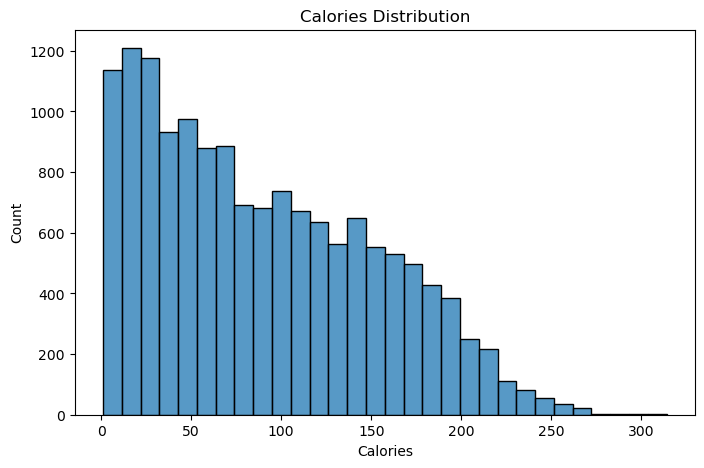

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Calories"], bins=30)

plt.title("Calories Distribution")

plt.show()

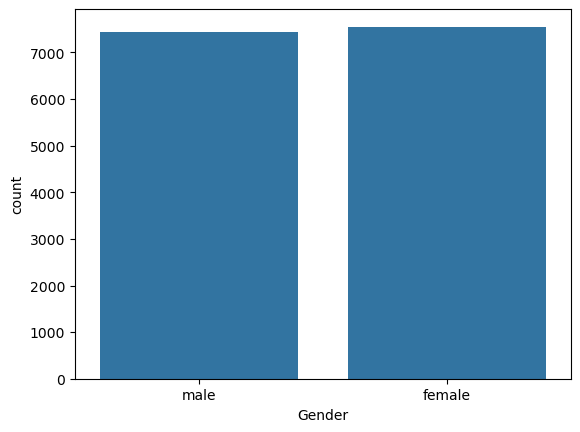

In [12]:
sns.countplot(x="Gender", data=df)

plt.show()

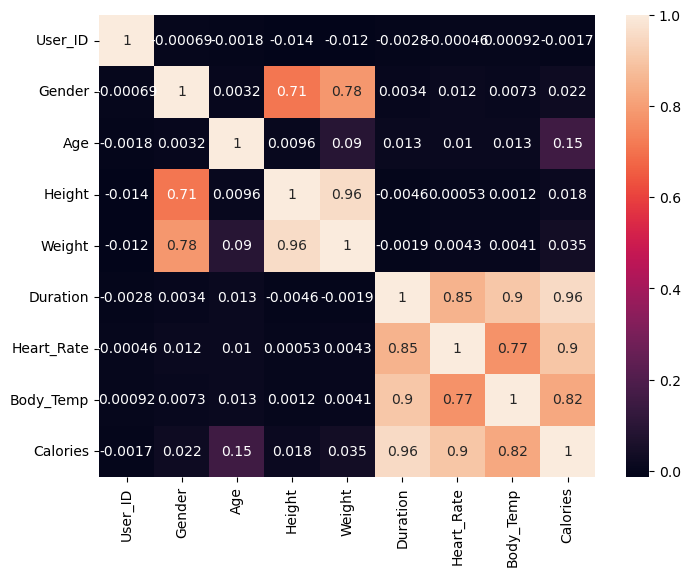

In [13]:
temp = df.copy()

temp["Gender"] = LabelEncoder().fit_transform(temp["Gender"])

plt.figure(figsize=(8,6))

sns.heatmap(temp.corr(), annot=True)

plt.show()

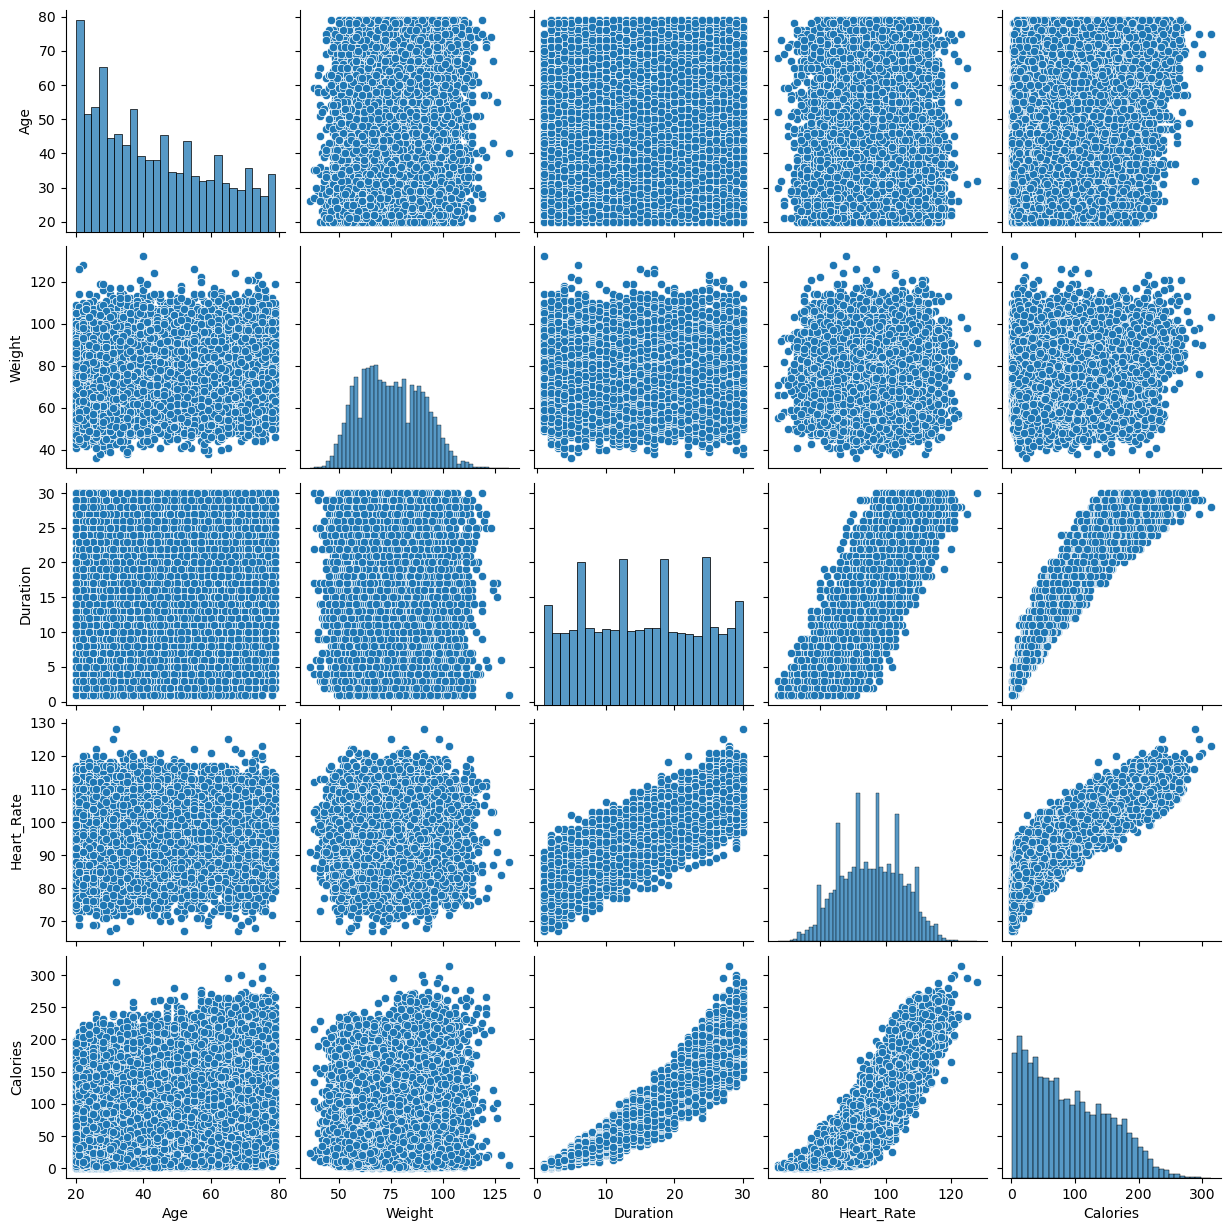

In [14]:
sns.pairplot(df[['Age','Weight','Duration','Heart_Rate','Calories']])

plt.show()

# Step 6 : Data Preprocessing

In [15]:
df.drop("User_ID", axis=1, inplace=True)

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0


In [16]:
X = df.drop("Calories", axis=1)

y = df["Calories"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 7 : Model Training

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [19]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [20]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Step 8 : Model Evaluation

In [21]:
models = {

"Linear Regression": lr_pred,

"Decision Tree": dt_pred,

"Random Forest": rf_pred

}

for name,pred in models.items():

    print(name)

    print("MAE :",mean_absolute_error(y_test,pred))

    print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

    print("R2 :",r2_score(y_test,pred))

    print()

Linear Regression
MAE : 8.441513553849715
RMSE : 11.48894014915288
R2 : 0.9672937151257295

Decision Tree
MAE : 3.437333333333333
RMSE : 5.335853571204267
R2 : 0.9929452912784914

Random Forest
MAE : 1.7173133333333332
RMSE : 2.6833820078401063
R2 : 0.9982158297720679



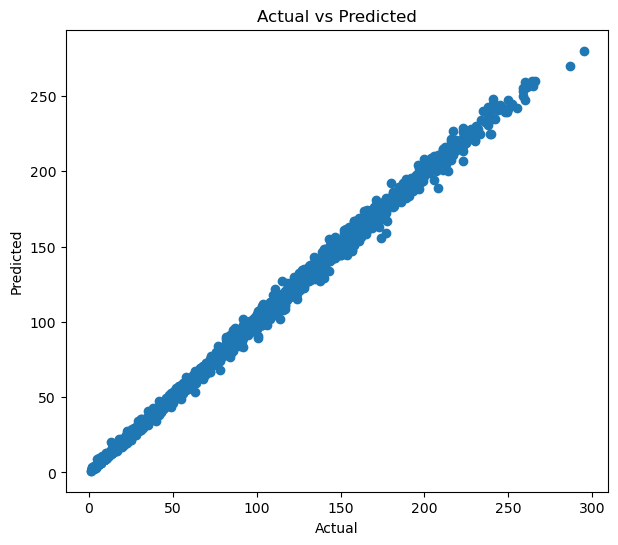

In [22]:
plt.figure(figsize=(7,6))

plt.scatter(y_test,rf_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [24]:
joblib.dump(rf,"D:/Coding/college/ML course/Projects/Calories Burnt Prediction/Calories-Burnt-Prediction/models/best_model.pkl")

['D:/Coding/college/ML course/Projects/Calories Burnt Prediction/Calories-Burnt-Prediction/models/best_model.pkl']

In [25]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Calories:",prediction[0])

Predicted Calories: 230.78


# Conclusion

Three machine learning regression algorithms were trained and evaluated.

Among them, the Random Forest Regressor achieved the highest accuracy on the dataset and was selected as the final model.

The trained model was saved and integrated into a Flask web application that provides real-time calorie prediction based on user inputs.